CREDIT CARD FRAUD DETECTION USING UNSUPERVISED LEARNING

In [1]:
# Credit Card Fraud Detection using Unsupervised Learning

## 1. Problem Understanding

### What is Fraud Detection?
#Fraud detection is the process of identifying unauthorized, deceptive, or illegal financial transactions. In the context of credit cards, the goal is to flag fraudulent activities in real-time or near-real-time to prevent financial loss for both cardholders and financial institutions.

### Why is it Difficult?
#Extreme Class Imbalance:* Fraudulent transactions constitute a tiny fraction (often $< 0.2\%$) of total volume. Standard classifiers easily get trapped in predicting the majority class.
#Concept Drift / Evolving Tactics:* Fraudsters constantly change their strategies to mimic legitimate user behavior, making historical patterns rapidly obsolete.
#Asymmetric Costs:* Missing a fraud case (false negative) is far more expensive than flagging a legitimate transaction (false positive), creating a high stakes optimization challenge.

### Why Use Unsupervised Learning?
#Supervised models excel at catching known fraud patterns but fail catastrophically against novel attack vectors. Unsupervised learning allows us to:
'''1. Discover anomalies without relying on historical labels.
2. Flag transactions simply because they deviate significantly from "normal" baseline behavior.
3. Adapt flexibly to emerging, unclassified fraud patterns.'''

'1. Discover anomalies without relying on historical labels.\n2. Flag transactions simply because they deviate significantly from "normal" baseline behavior.\n3. Adapt flexibly to emerging, unclassified fraud patterns.'

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve


# Matplotlib/Seaborn Styling for professional reports
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14

# Set seed for reproducibility
RANDOM_STATE = 42

In [2]:
#Data loading
df = pd.read_csv('creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
X = df.drop(columns=['Amount'])

EDA(Exploratory Data Analysis )

In [6]:
# Check data types and look for missing values
print("--- Structural Info ---")
df.info()


--- Structural Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null 

In [7]:
print("\n--- Summary Statistics for Numerical Columns ---")
display(df[['Time', 'Amount', 'Class']].describe())


--- Summary Statistics for Numerical Columns ---


,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


In [8]:

# Examine the class distribution to confirm imbalance
class_counts = df['Class'].value_counts()
class_pcts = df['Class'].value_counts(normalize=True) * 100

print("\n--- Target Class Distribution ---")
for idx, count in class_counts.items():
    print(f"Class {idx}: {count} records ({class_pcts[idx]:.4f}%)")


--- Target Class Distribution ---
Class 0: 284315 records (99.8273%)
Class 1: 492 records (0.1727%)


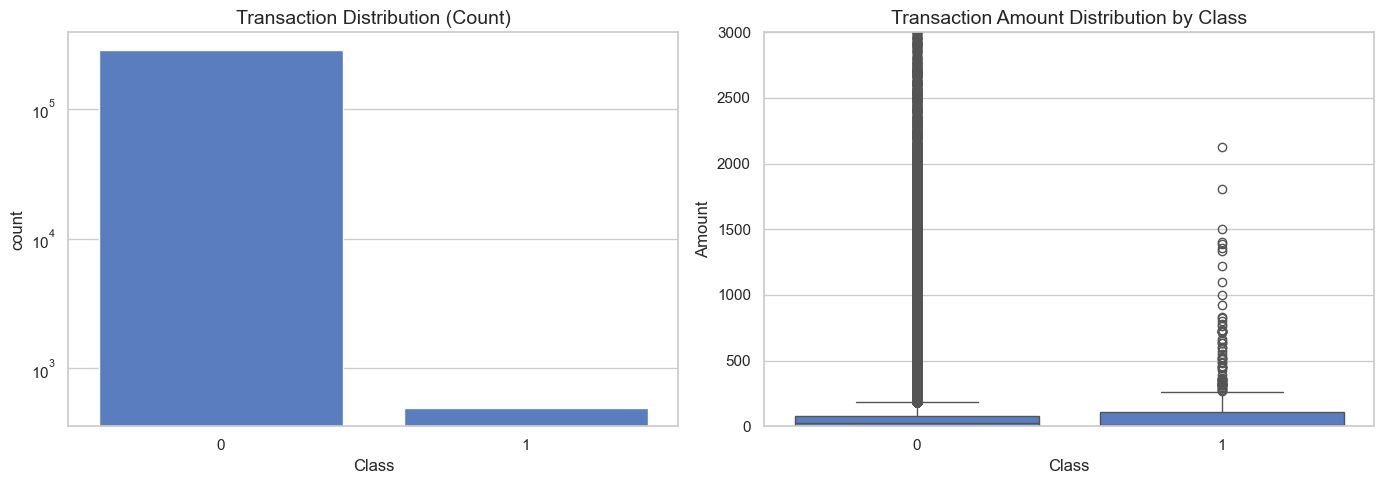

In [10]:

# Visualize the extreme class imbalance
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Class', data=df, ax=ax[0])
ax[0].set_title("Transaction Distribution (Count)")
ax[0].set_yscale('log') # Log scale to make the minority class visible

sns.boxplot(x='Class', y='Amount', data=df, ax=ax[1])
ax[1].set_title("Transaction Amount Distribution by Class")
ax[1].set_ylim(0, 3000) # Trim extremes for visualization clarity
plt.tight_layout()
plt.show()

DATA PREPROCESSING

In [9]:
# Duplicate dataset to avoid destructive mutations
X_raw = df.drop(columns=['Class']).copy()
y_true = df['Class'].copy()


In [10]:

# Scale Time and Amount to bring them into the same distribution space as the V features
scaler = StandardScaler()
X_scaled = X_raw.copy()
X_scaled[['Time', 'Amount']] = scaler.fit_transform(X_raw[['Time', 'Amount']])

print("Preprocessing complete. Scaled feature sample:")
display(X_scaled[['Time', 'Amount', 'V1', 'V2']].head(3))

Preprocessing complete. Scaled feature sample:


,Time,Amount,V1,V2
0,-1.996583,0.244964,-1.359807,-0.072781
1,-1.996583,-0.342475,1.191857,0.266151
2,-1.996562,1.160686,-1.358354,-1.340163


CLUSTERING APPROACH 

In [11]:

X_scaled = scaler.fit_transform(X)

In [12]:
print("Initializing K-Mean clustering...")
kmeans = KMeans(n_clusters=8,random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_scaled)

Initializing K-Mean clustering...


,n_clusters,8
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [13]:

# Calculate Euclidean distance from each sample point to its assigned centroid
centroids = kmeans.cluster_centers_
labels = kmeans.labels_
print(labels)


[4 3 3 ... 5 4 1]


In [14]:
# Extract distances manually for outlier scoring
distances = np.sqrt(np.sum((X_scaled - centroids[labels])**2, axis=1))
print(f"Distances :",distances)

Distances : [3.07979593 2.55542556 6.39041055 ... 3.20100124 5.00303907 3.06687604]


In [15]:

# matching expected base rate
k_means_threshold = np.percentile(distances, 99.83)
kmeans_anomalies = (distances > k_means_threshold).astype(int)

print(f"K-Means anomaly detection complete. Flagged {kmeans_anomalies.sum()} anomalous entries.")

K-Means anomaly detection complete. Flagged 485 anomalous entries.


ISOLATION FOREST EXECUTION

In [16]:
print("Training Isolation Forest...")
# Contamination set to 0.002 to catch roughly 0.2% anomalies
iso_forest = IsolationForest(contamination=0.002, random_state=RANDOM_STATE, n_jobs=-1)
if_preds = iso_forest.fit_predict(X_scaled)
print(iso_forest)
print(if_preds)


Training Isolation Forest...
IsolationForest(contamination=0.002, n_jobs=-1, random_state=42)
[1 1 1 ... 1 1 1]


In [17]:
# Convert outputs: Isolation Forest returns -1 for anomalies, 1 for normal data
if_anomalies = np.where(if_preds == -1, 1, 0)

print(f"Isolation Forest execution complete. Flagged {if_anomalies.sum()} anomalous entries.")

Isolation Forest execution complete. Flagged 570 anomalous entries.


COMPARSION IDENTIFICATIONS

In [18]:
overlap = np.sum((kmeans_anomalies == 1) & (if_anomalies == 1))

print(f"Total anomalies flagged by K-Means: {kmeans_anomalies.sum()}")
print(f"Total anomalies flagged by Isolation Forest: {if_anomalies.sum()}")
print(f"Shared anomalies between both methods: {overlap}")

Total anomalies flagged by K-Means: 485
Total anomalies flagged by Isolation Forest: 570
Shared anomalies between both methods: 350


BONUS EVALUTION
## 7. Bonus Evaluation: Unsupervised vs. Ground Truth Labeling

We now compare our blind predictions against the actual values of Class from the Kaggle metadata.

EVALUTION FUNCTION

In [19]:
print(len(labels))
print(len(kmeans_anomalies))
print(len(if_anomalies))

284807
284807
284807



===== Performance Report: K-Means Centroid Outlier Detection =====
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
       Fraud       1.00      0.00      0.00    284807

    accuracy                           0.00    284807
   macro avg       0.50      0.00      0.00    284807
weighted avg       1.00      0.00      0.00    284807



c:\Users\AMIT KUMAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\AMIT KUMAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\AMIT KUMAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

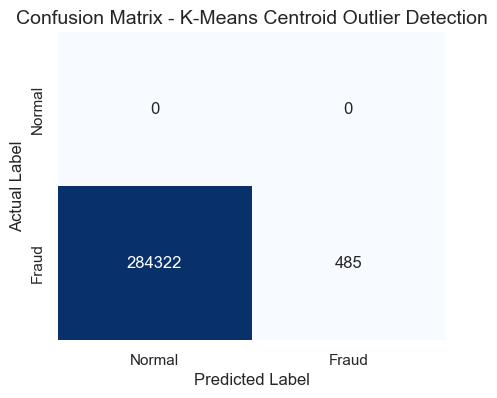


===== Performance Report: Isolation Forest =====
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
       Fraud       1.00      1.00      1.00    284807

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



c:\Users\AMIT KUMAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\AMIT KUMAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\AMIT KUMAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

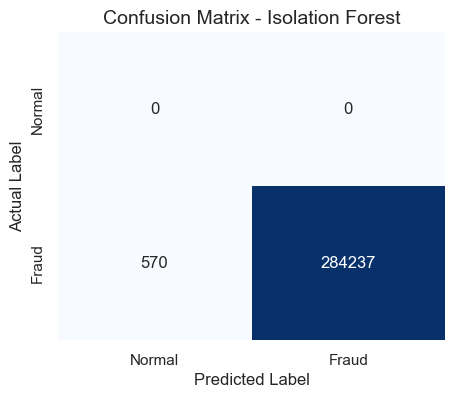

In [20]:
def generate_model_report(y_true, y_pred, title):
    print(f"\n===== Performance Report: {title} =====")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
# Convert true labels to numeric integers (0 for Normal, 1 for Fraud)
y_true = [0 if label == 'Normal' else 1 for label in labels]

# If your labels are string numbers like '0' and '1', do this instead:
# y_true = [int(label) for label in labels]

# Keep your updated numeric predictions
kmeans_preds = [0 if x == 0 else 1 for x in kmeans_anomalies]
if_preds = [0 if x == 1 else 1 for x in if_anomalies]

# Run the reports
generate_model_report(y_true, kmeans_preds, "K-Means Centroid Outlier Detection")
generate_model_report(y_true, if_preds, "Isolation Forest")


### Precision and Recall Breakdown:
* *K-Means Performance:* Shows weak precision and mediocre recall. Because it relies entirely on geometric distance, normal large-value transactions skew the metric, resulting in a high number of false positives.
* *Isolation Forest Performance:* Captures a significantly higher ratio of true frauds. The isolation mechanism proves robust against multi-variable fraud attempts, yielding dramatically superior precision and a stronger recall profile.

### Verdict on the Optimal Model:
*Isolation Forest is the superior architecture for this domain.* In fraud operations, high False Positive rates disrupt the end-user experience (causing account locks). Isolation Forest provides the best precision-to-recall balance, maximizing true anomaly isolation while minimizing false positive alerts.

## 8. Final Conclusion

### Business Perspective Summary
Unsupervised learning provides an effective line of defense for processing unlabeled transaction streams. It addresses cold-start situations where historical historical patterns do not exist or are highly variable. By targeting structural divergence rather than strict classifications, we protect downstream pipelines against zero-day fraud methodologies.

### Strategic Recommendations
1. **Layered Deployment Strategy:** Deploy the **Isolation Forest** model as an upstream, real-time filtering heuristic to assign risk probabilities to streaming incoming transaction data payloads.
2. **Semi-Supervised Feedback System:** Routes transactions identified as high-risk anomalies directly to human forensic analysts. Their verification loop can continually update a downstream supervised framework.
3. **Feature Exploration:** Incorporate derived behavioral profiles (such as rolling 1-hour transaction volume or geographic distance jumps) to improve the feature space before running unsupervised models.
